# 235. Lowest Common Ancestor of a Binary Search Tree
https://leetcode.com/problems/lowest-common-ancestor-of-a-binary-search-tree/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Generic LCA (Problem 236) | O(n) | O(n) | Ignores BST property |
| Recursive BST | O(h) | O(h) | Exploit BST ordering |
| **Iterative BST** | **O(h)** | **O(1)** | **Walk down using BST property** |

## Methodology

In a BST, if both `p` and `q` are smaller than the current node, LCA is in the left subtree. If both are larger, LCA is in the right subtree. Otherwise, the current node is the **split point** and thus the LCA. The iterative approach avoids recursion stack overhead, achieving O(1) space.

## Solutions

### C#

In [ ]:
// 235. Lowest Common Ancestor of a Binary Search Tree
// Time: O(h) | Space: O(1)
public class TreeNode {
    public int val;
    public TreeNode left;
    public TreeNode right;
    public TreeNode(int x) { val = x; }
}

public class Solution {
    public TreeNode LowestCommonAncestor(TreeNode root, TreeNode p, TreeNode q) {
        TreeNode node = root;
        while (node != null) {
            if (p.val < node.val && q.val < node.val)
                node = node.left;
            else if (p.val > node.val && q.val > node.val)
                node = node.right;
            else
                return node;
        }
        return null;
    }
}

### Python

In [ ]:
# 235. Lowest Common Ancestor of a Binary Search Tree
# Time: O(h) | Space: O(1)
class TreeNode:
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None

class Solution:
    def lowestCommonAncestor(self, root: TreeNode, p: TreeNode, q: TreeNode) -> TreeNode:
        node = root
        while node:
            if p.val < node.val and q.val < node.val:
                node = node.left
            elif p.val > node.val and q.val > node.val:
                node = node.right
            else:
                return node
        return None

### Go

In [ ]:
// 235. Lowest Common Ancestor of a Binary Search Tree
// Time: O(h) | Space: O(1)
type TreeNode struct {
    Val   int
    Left  *TreeNode
    Right *TreeNode
}

func lowestCommonAncestor(root, p, q *TreeNode) *TreeNode {
    node := root
    for node != nil {
        if p.Val < node.Val && q.Val < node.Val {
            node = node.Left
        } else if p.Val > node.Val && q.Val > node.Val {
            node = node.Right
        } else {
            return node
        }
    }
    return nil
}

### Rust

In [ ]:
// 235. Lowest Common Ancestor of a Binary Search Tree
// Time: O(h) | Space: O(1)
use std::rc::Rc;
use std::cell::RefCell;

#[derive(Debug, PartialEq, Eq)]
pub struct TreeNode {
    pub val: i32,
    pub left: Option<Rc<RefCell<TreeNode>>>,
    pub right: Option<Rc<RefCell<TreeNode>>>,
}

impl Solution {
    pub fn lowest_common_ancestor(
        root: Option<Rc<RefCell<TreeNode>>>,
        p: Option<Rc<RefCell<TreeNode>>>,
        q: Option<Rc<RefCell<TreeNode>>>,
    ) -> Option<Rc<RefCell<TreeNode>>> {
        let pv = p.as_ref().unwrap().borrow().val;
        let qv = q.as_ref().unwrap().borrow().val;
        let mut node = root;
        while let Some(n) = node {
            let val = n.borrow().val;
            if pv < val && qv < val {
                node = n.borrow().left.clone();
            } else if pv > val && qv > val {
                node = n.borrow().right.clone();
            } else {
                return Some(n);
            }
        }
        None
    }
}

## Example Scenarios

### 1. Common Case — Split at Root
**Input:** BST `[6,2,8,0,4,7,9]`, `p = 2`, `q = 8`

Since $p < 6 < q$, the nodes lie on opposite sides of the root. The search never descends — the root `6` is the LCA.

### 2. Slightly Complex — Ancestor Is One of the Nodes
**Input:** BST `[6,2,8,0,4,7,9,null,null,3,5]`, `p = 2`, `q = 4`

Both $p$ and $q$ are $\le 6$, so we go left. At node `2`, $q = 4$ is in the right subtree and $p = 2$ is the current node. Since one node equals the current, LCA is `2`.

### 3. Edge Case: Time Factor — Deep Skewed BST
**Input:** BST `[1,null,2,null,3,...,null,10000]` (right-skewed chain of $10{,}000$ nodes), `p = 9999`, `q = 10000`

The algorithm walks the entire right spine — $O(h) = O(n)$ in a skewed tree. It finally finds $p < \text{node} = q$ at node `10000`, returning `9999` as LCA after $9{,}999$ steps.

### 4. Edge Case: Space Factor — Recursive Stack on Deep Tree
**Input:** BST with $10^4$ nodes in a left-skewed chain, `p = 1`, `q = 2`

A recursive solution would push $O(n)$ frames onto the call stack. The iterative approach uses $O(1)$ space regardless of tree shape, making it immune to stack overflow.

### 5. Almost-Impossible but Plausible — Identical Values at Boundary
**Input:** BST `[2,1,3]`, `p = 1`, `q = 3`

With the smallest possible BST containing both targets, $p < 2 < q$ so the root splits them immediately. Even with $p = q$ (same node), the algorithm returns that node in $O(1)$. The constraint $p \neq q$ guarantees two distinct nodes, but the logic handles equality gracefully.

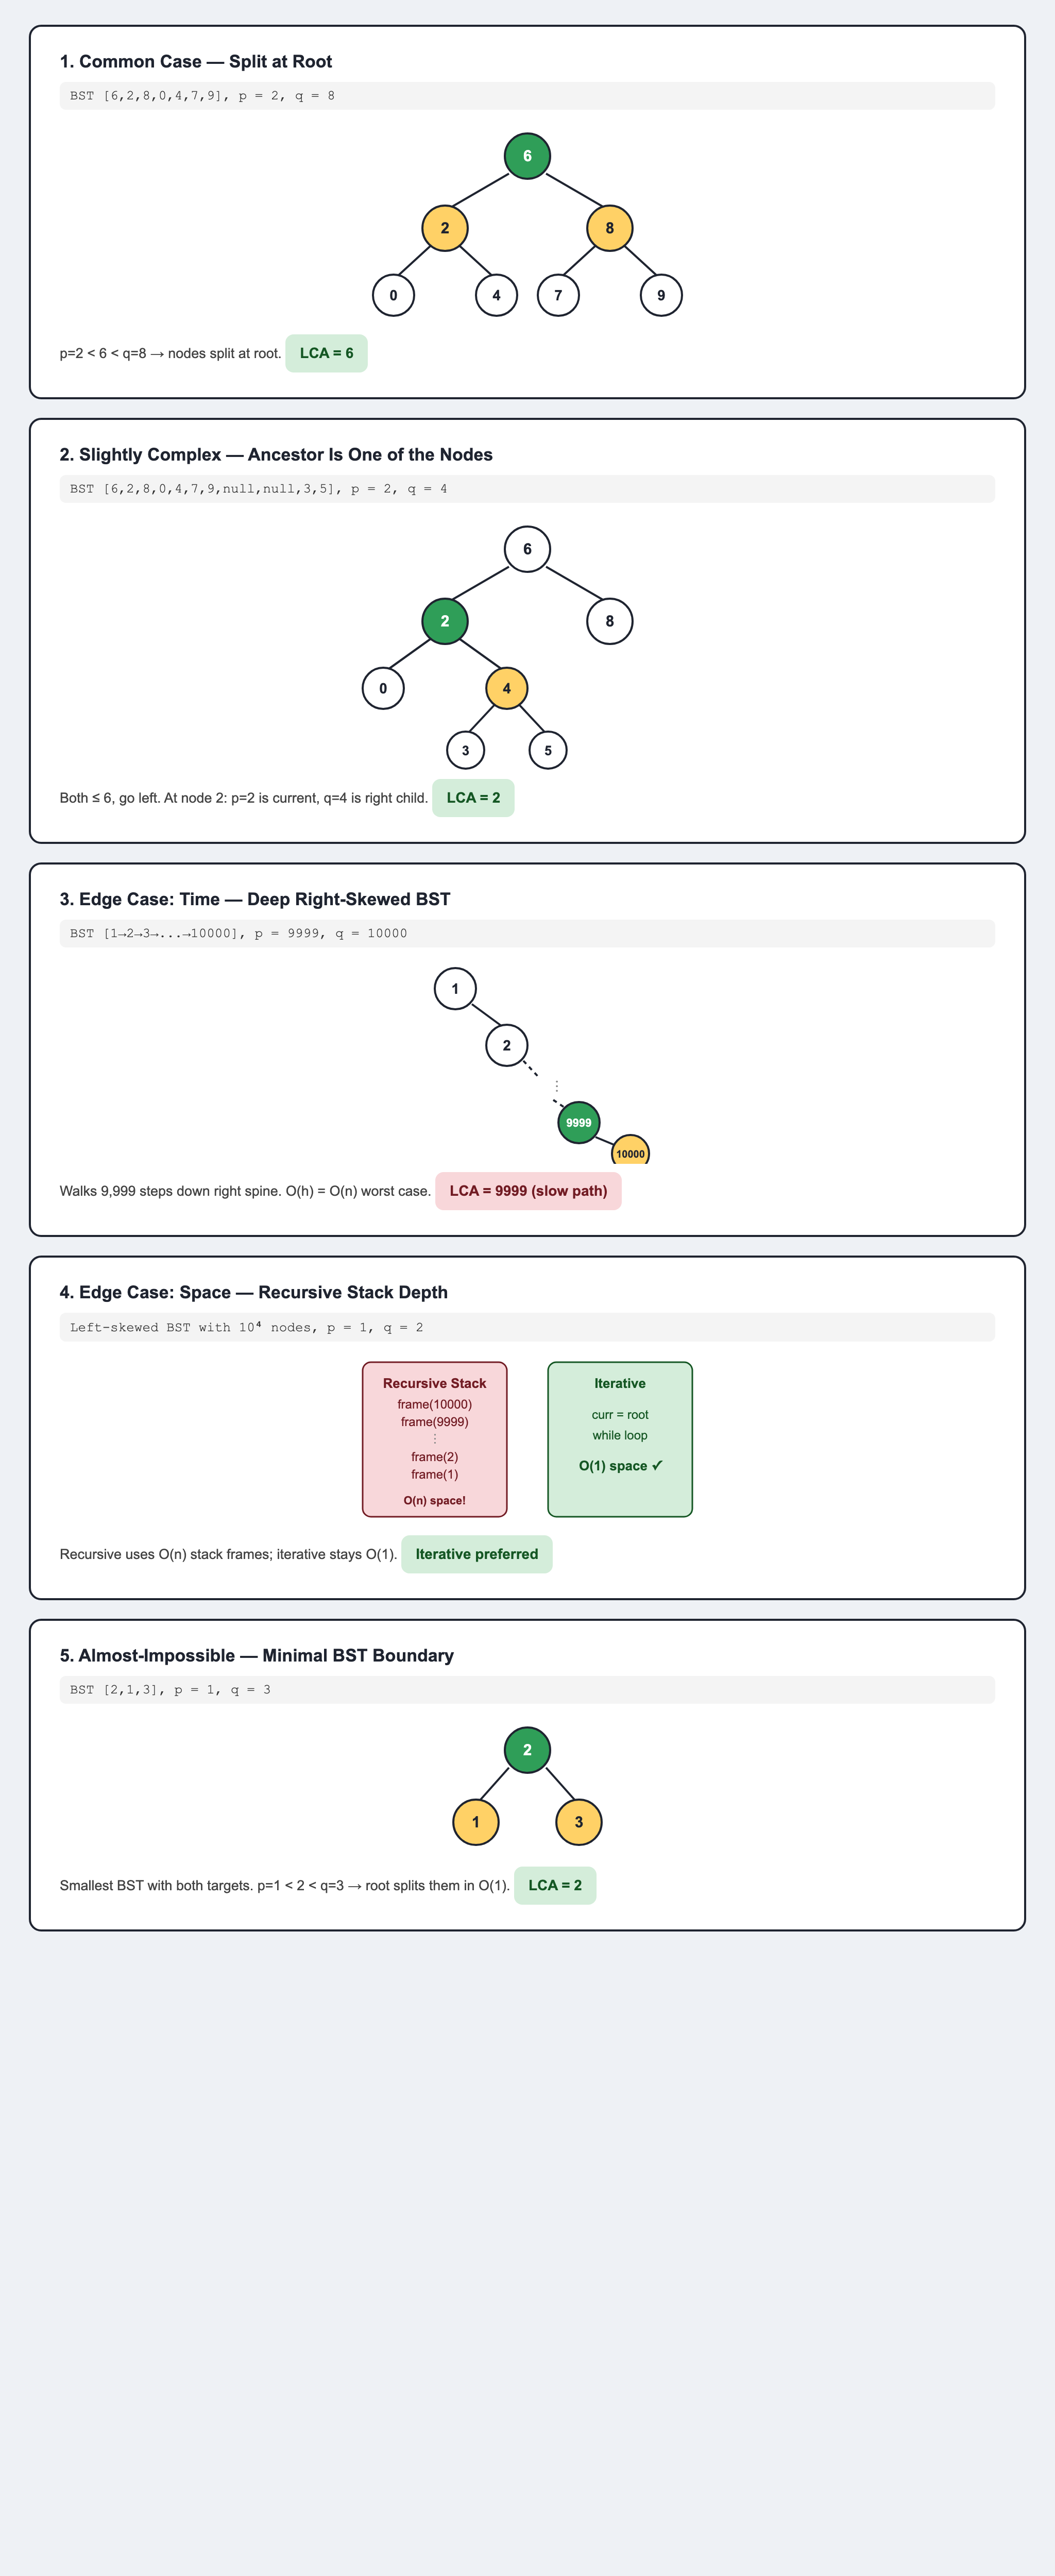